In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [542]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [346]:
def plot_histogram(df, prop, labels=None, bins=100, log=True):
    labelsize = 55
    x_tick_major_size = 16
    x_tick_major_width = 4
    x_tick_minor_size = 8
    x_tick_minor_width = 3
    fig_width = 25
    fig_height = 15
    axes_width = 3
    tick_labelsize = 35
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    
    if labels == None:
        if prop == 'Column_dens_r':
            x_label = r'$\log(\rho)[\log(\mathrm{gcm}^{-3})]$'
            y_label = r'p.d.f.($\log(\rho)$)'
            labels = {'x':x_label, 'y':y_label}
        elif prop == 'Column_height_r':
            x_label = '$\log(h)[\log(\mathrm{cm})]$'
            y_label = r'p.d.f.($\log(h)$)'
            labels = {'x':x_label, 'y':y_label}
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    ax.set_xlabel(labels['x'], size=labelsize)
    ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [601]:
!ls /ptmp/mpa/ivkos/semianalytic_fesc/sn013/

dataset_reduced.pickle	reduced_df_update1.pickle
full_dataset.pickle	reduced_df_update2.pickle


In [599]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/dataset_reduced.pickle'
df_new = pd.read_pickle(df_path)

In [650]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/reduced_df_update2.pickle'
df = pd.read_pickle(df_path)

In [651]:
test_df = df.iloc[1000:10000].copy(deep=True)

In [465]:
from calculate_fesc import update_to_fesc

In [490]:
from astropy import units as u

In [658]:
update_to_fesc(df)

/freya/u/ivkos/semianalytic/calculate_fesc.py:114: RuntimeWarning: divide by zero encountered in double_scalars
  * ((1-element['N_ratio_r']) / element['N_ratio_r']))**(1/3)
/freya/u/ivkos/semianalytic/calculate_fesc.py:113: RuntimeWarning: invalid value encountered in double_scalars
  return 6*(element['Dust_norm_r'] * element['U1_r']
/freya/u/ivkos/semianalytic/calculate_fesc.py:151: RuntimeWarning: divide by zero encountered in double_scalars
  * (1/element['Column_dens_stroemgren_r']


In [681]:
df.columns

Index(['Z_2r', 'Z_r', 'r', 'SFR_r', 'SFR_2r', 'Halo_pos_x', 'Halo_pos_y',
       'Halo_pos_z', 'M_gas_2r', 'V_gas_2r', 'M_star_2r', 'M_gas_r', 'V_gas_r',
       'M_star_r', 'Redshift', 'Column_height_r', 'Column_height_2r',
       'Column_dens_r', 'Column_dens_2r', 'Sigma_SFR_r', 'Sigma_SFR_2r',
       'Sigma_gas_r', 'Sigma_gas_2r', 'Sigma_star_r', 'Sigma_star_2r',
       'Ion_flux_r', 'Ion_flux_2r', 'Bol_flux_r', 'Bol_flux_2r', 'Lum_sf',
       'Ion_lum_sf', 'M_gas_sf', 'SFR_sf', 'M_star_sf', 'V_gas_sf', 'Z_sf',
       'Dust_norm_r', 'Dust_norm_2r', 'f_g_r', 'f_g_2r', 'N_d_r', 'N_d_2r',
       'sigma_d_H_r', 'sigma_d_H_2r', 'p_g_r', 'p_g_2r', 'n_gas_r', 'n_gas_2r',
       'U_r', 'U_2r', 'Column_dens_stroemgren_r', 'Column_dens_stroemgren_2r',
       'U1_r', 'U1_2r', 'tau_d_r', 'tau_d_2r', 'p_r_r', 'p_r_2r', 'v_inf_r',
       'v_inf_2r', 'N_ratio_r', 'N_ratio_2r', 'f_g_crit_r', 'f_g_crit_2r',
       'w_r', 'w_2r', 'N_red_r', 'N_red_2r', 'f_esc_r', 'f_esc_2r'],
      dtype='object')

In [660]:
df['f_esc_r'].describe()

count    191567.000000
mean          0.029202
std           0.157918
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: f_esc_r, dtype: float64

In [686]:
df[df.f_esc_r>0.01]['w_r'].describe()

count    8339.000000
mean        0.416214
std         0.397650
min         0.000000
25%         0.000000
50%         0.281566
75%         1.000000
max         1.000000
Name: w_r, dtype: float64

In [684]:
df['w_r'].describe()

count    191567.000000
mean          0.056773
std           0.117834
min           0.000000
25%           0.019479
50%           0.032952
75%           0.052594
max           1.000000
Name: w_r, dtype: float64

In [677]:
emm_fesc = np.sum(test_df['f_esc_r']*test_df['Ion_flux_r']*test_df['r']**2)/np.sum(test_df['Ion_flux_r']*test_df['r']**2)

In [678]:
emm_fesc

0.45298702983035755

In [674]:
df['f_esc_r']

0          1.000000
1          0.019616
2          0.032766
3          0.000000
4          0.058016
             ...   
2317355    0.000000
2329332    0.000000
2351454    0.000000
2368557    0.000000
2745125    0.000000
Name: f_esc_r, Length: 191567, dtype: float64

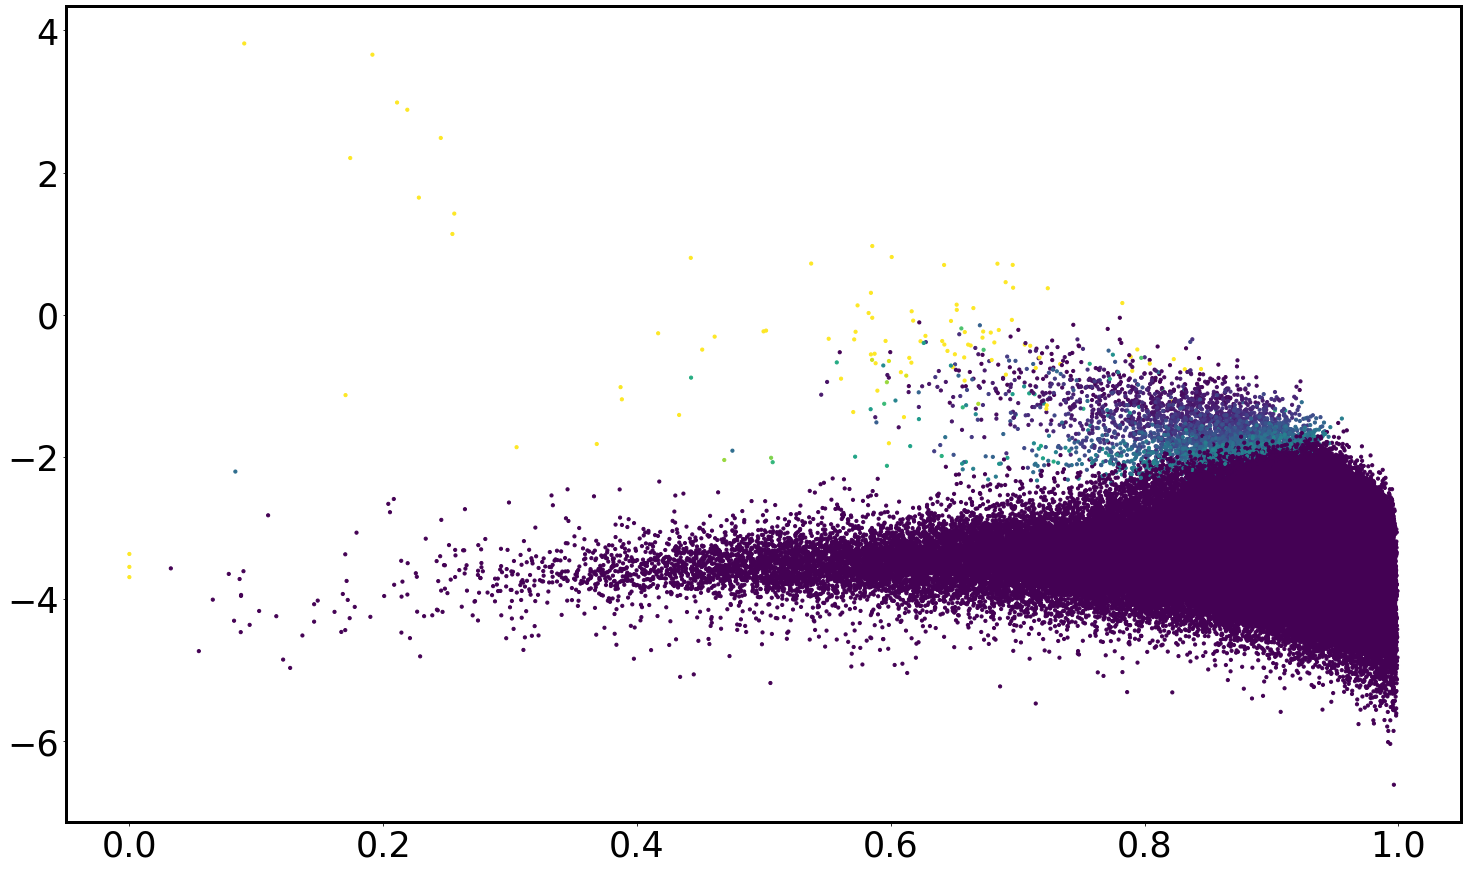

In [665]:
plt.scatter(df['f_g_r'], np.log10(df['Sigma_SFR_r']/conv**2), s=10, c=df['f_esc_r'])

In [455]:
from astropy import constants

In [451]:
test_df[['M_gas_sf','SFR_sf','M_star_sf', 'V_sf' ,'Z_sf', 'M_gas_2r','SFR_2r','M_star_2r', 'V_gas_2r' ,'Z_2r']]

,M_gas_sf,SFR_sf,M_star_sf,V_sf,Z_sf,M_gas_2r,SFR_2r,M_star_2r,V_gas_2r,Z_2r
11642,3.290392e+38,0.088983,8.772462e+36,4.921752e+65,0.002214,4.001029e+38,0.088840,4.725922e+42,1.356197e+66,0.002046
11643,2.730061e+38,0.100428,1.775720e+37,2.284411e+65,0.002885,1.734530e+38,0.067313,5.489115e+42,2.930771e+65,0.003636
11644,1.917824e+38,0.046203,8.452027e+36,3.294481e+65,0.002648,2.239937e+38,0.043965,3.463720e+42,8.143030e+65,0.002666
11645,7.572045e+37,0.017684,4.305082e+36,1.286016e+65,0.002326,1.047919e+38,0.017453,1.702506e+42,4.793290e+65,0.002009
11648,1.742100e+37,0.002968,4.299958e+35,4.936932e+64,0.001532,2.128349e+37,0.002748,7.925460e+41,9.462819e+64,0.001504
...,...,...,...,...,...,...,...,...,...,...
12734,1.235582e+37,0.002069,1.365285e+35,3.638878e+64,0.000450,4.257291e+37,0.002069,1.467678e+41,4.521189e+65,0.000409
12735,1.638463e+37,0.003182,3.726886e+35,3.709624e+64,0.000772,1.764894e+37,0.002692,1.174142e+41,9.055707e+64,0.000786
12738,1.598729e+37,0.002645,1.854264e+35,4.813052e+64,0.000281,1.597642e+36,0.000201,5.870711e+40,5.983418e+63,0.000438
12739,2.016287e+36,0.000285,2.059344e+35,8.268444e+63,0.001246,2.347902e+37,0.000285,2.054749e+41,2.304596e+65,0.000912


In [436]:
start = time.time()
add_sf_quantities(test_df, simpath, 13, z)
print(f'Needed {time.time()-start} seconds')

Working on subhalo 11642
Working on subhalo 11643
Working on subhalo 11644
Working on subhalo 11645
Working on subhalo 11646
Working on subhalo 11648
Working on subhalo 11650
Working on subhalo 11651
Working on subhalo 11655
Working on subhalo 11659
Working on subhalo 11670
Working on subhalo 11819


/freya/u/ivkos/pybpass/pyBPASS/database.py:149: UserWarning: Input ages for interpolation outside of available range 1000000.0, 100000000000.0 [yr] provided. They will be clipped.
  _warnings.warn(


Working on subhalo 11820
Working on subhalo 11821
Working on subhalo 11822
Working on subhalo 11823
Working on subhalo 11824
Working on subhalo 11825
Working on subhalo 11826
Working on subhalo 11827
Working on subhalo 11828
Working on subhalo 11829
Working on subhalo 11830
Working on subhalo 11831
Working on subhalo 11833
Working on subhalo 11837
Working on subhalo 11840
Working on subhalo 11842
Working on subhalo 11843
Working on subhalo 11848
Working on subhalo 11849
Working on subhalo 11856
Working on subhalo 11859
Working on subhalo 12023
Working on subhalo 12024
Working on subhalo 12025
Working on subhalo 12029
Working on subhalo 12030
Working on subhalo 12032
Working on subhalo 12046
Working on subhalo 12163
Working on subhalo 12165
Working on subhalo 12258
Working on subhalo 12259
Working on subhalo 12260
Working on subhalo 12261
Working on subhalo 12262
Working on subhalo 12263
Working on subhalo 12264
Working on subhalo 12265
Working on subhalo 12267
Working on subhalo 12268


In [382]:
x_label = r'$\log(N_r)[\log(\mathrm{cm}^{-2})]$'
y_label = r'p.d.f.($\log(N_r)$)'
labels = {'x':x_label, 'y':y_label}

In [390]:
x_label = '$\log(h_r)[\log(\mathrm{cm})]$'
y_label = r'p.d.f.($\log(h_r)$)'
labels = {'x':x_label, 'y':y_label}

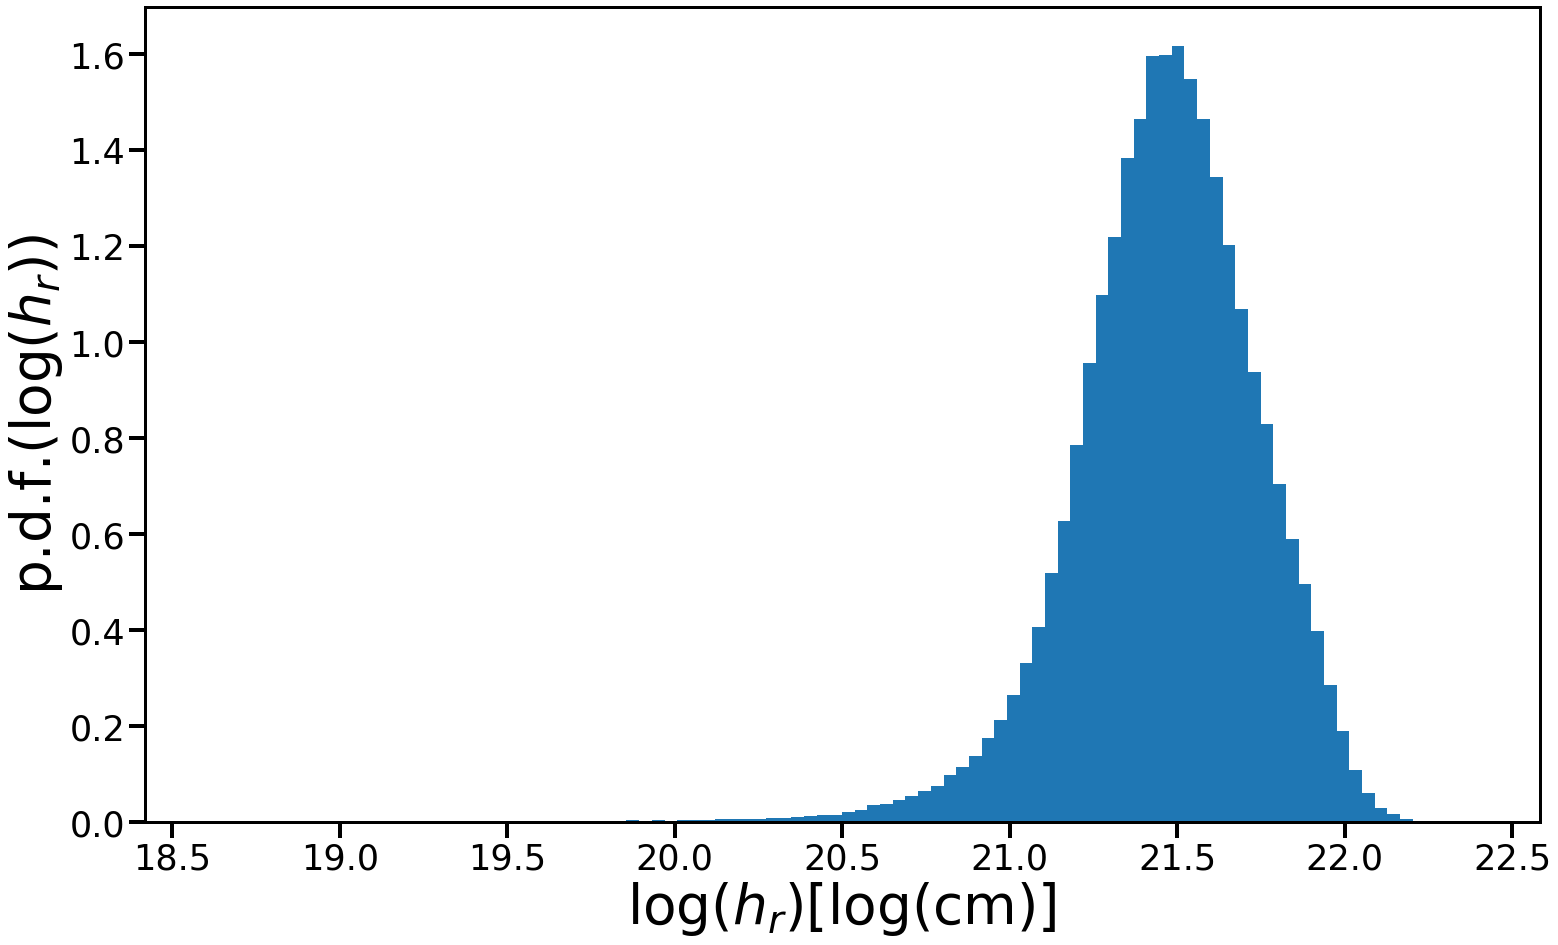

In [392]:
plot_histogram(df=df[df.Column_height_r != 0], prop='Column_height_r', log=True, labels=labels)

In [384]:
x_label = r'$\log(N_{2r})[\log(\mathrm{cm}^{-2})]$'
y_label = r'p.d.f.($\log(N_{2r})$)'
labels = {'x':x_label, 'y':y_label}

In [386]:
x_label = '$\log(h_{2r})[\log(\mathrm{cm})]$'
y_label = r'p.d.f.($\log(h_{2r})$)'
labels = {'x':x_label, 'y':y_label}

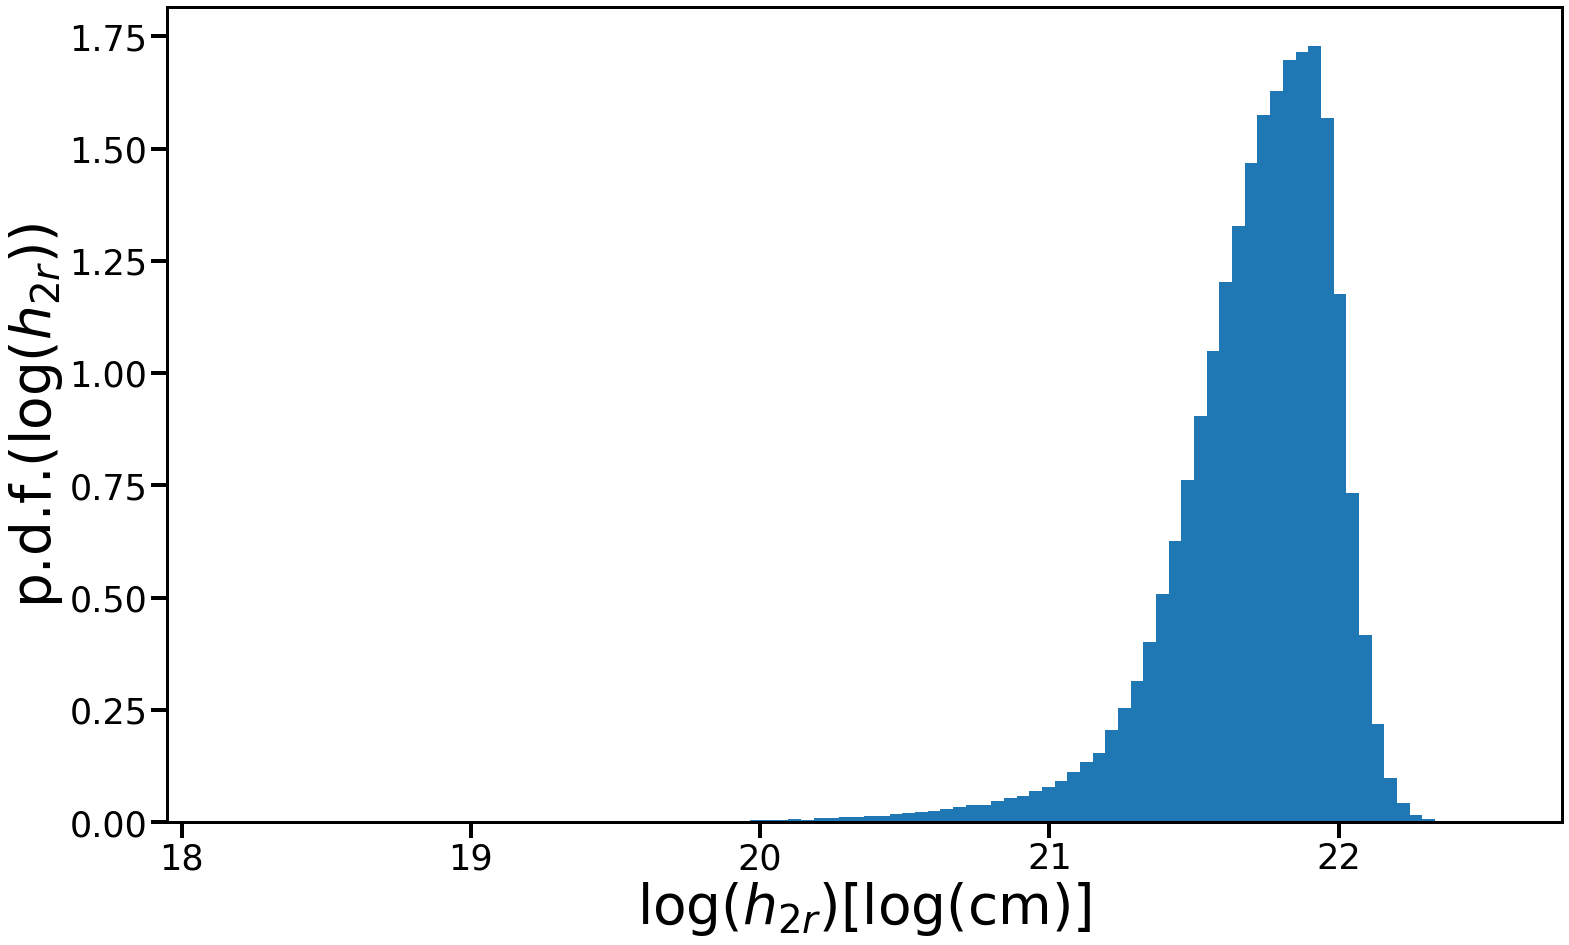

In [389]:
plot_histogram(df=df[df.Column_height_r != 0], prop='Column_height_2r', log=True, labels=labels)

In [388]:
df.Column_height_r.describe()

count    2.813490e+05
mean     3.420892e+21
std      2.090699e+21
min      0.000000e+00
25%      1.981654e+21
50%      2.965221e+21
75%      4.381284e+21
max      2.464664e+22
Name: Column_height_r, dtype: float64

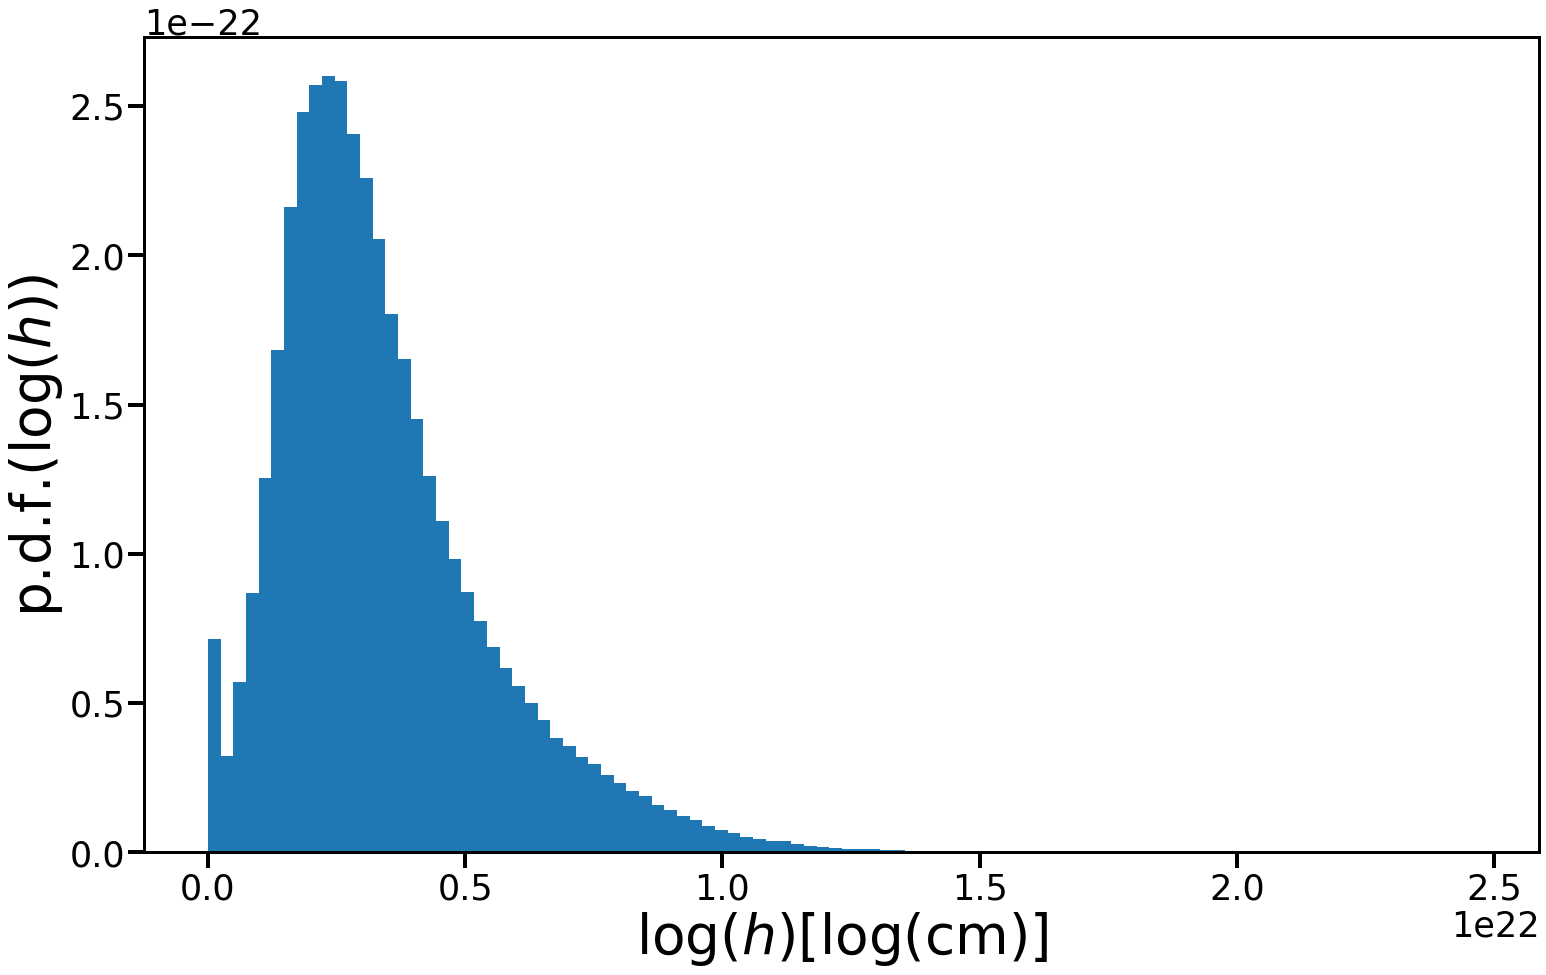

In [341]:
plot_histogram(df, prop='Column_height_r', log=False)

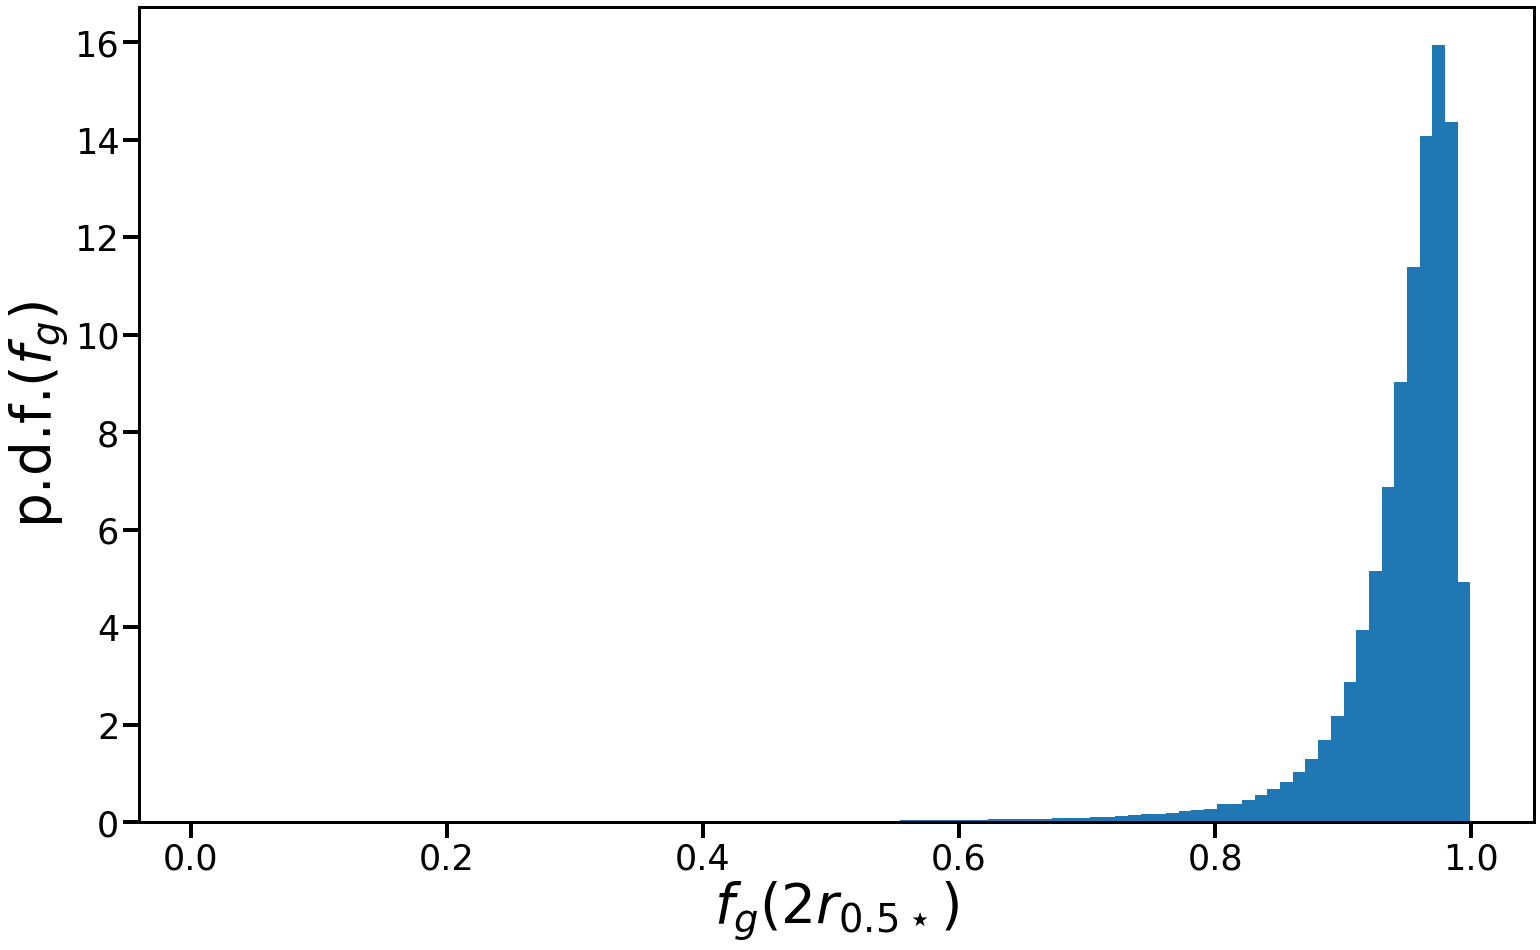

In [299]:
plot_histogram(df=df, prop='f_g_2r', labels=labels, log=False)